# LECTURE 4
**Topic:** Phasors; Discrete-Time Sinusoids  
**Textbook References:** Sections 1.4, 1.5

---

## Key Points

- The **stationary phasor** of $A\cos(\Omega t+\phi)$ is $Ae^{j\phi}$. The sum of sinusoids of **identical frequency** is found by adding their phasors.
- Discrete-time parameter $n$ counts samples; $\omega$ (rad/sample) is an angle increment. **No physical time** involved.
- Frequencies $\omega$ and $\omega+2\pi$ produce the **same signal** in discrete time.
- Real sinusoids: $\omega$ and $2\pi-\omega$ describe the same signal: $\cos(\omega n+\phi)=\cos((2\pi-\omega)n-\phi)$.
- Effective range for real sinusoids: $\omega\in[0,\pi]$.
- A DT sinusoid is periodic iff $\omega=(k/N)\cdot 2\pi$ for integers $k,N$.


---
## Theory and Examples

### 1. The Stationary Phasor

Since $\cos\theta=\Re\{e^{j\theta}\}$, the sinusoid $x(t)=A\cos(\Omega t+\phi)$ is the real part of:
$$z(t) = Ae^{j(\Omega t+\phi)} = \underbrace{Ae^{j\phi}}_{\text{stationary phasor}} \cdot e^{j\Omega t}$$

On the complex plane, $z(t)$ rotates counterclockwise with angular velocity $\Omega$ on a circle of radius $A$.  
The initial position $z(0) = Ae^{j\phi}$ is the **stationary phasor**.

### 2. Adding Sinusoids with the Same Frequency

$$A_1\cos(\Omega t+\phi_1) + A_2\cos(\Omega t+\phi_2) = \Re\{(A_1e^{j\phi_1}+A_2e^{j\phi_2})e^{j\Omega t}\} = A\cos(\Omega t+\phi)$$

where $Ae^{j\phi} = A_1e^{j\phi_1} + A_2e^{j\phi_2}$ (complex sum of stationary phasors).

> **Key Insight:** Phasor addition converts sinusoid addition into complex vector addition. You cannot simply add the amplitudes!


=== Phasor Addition: 2.7cos(15pi t+0.6) + 4.1sin(15pi t-1.8) ===
  sin(x) = cos(x-pi/2), so 4.1 sin(15pi t - 1.8) = 4.1 cos(15pi t + -3.3708)
  Phasor 1: 2.7*e^(j*0.6) = 2.2284+1.5245j
  Phasor 2: 4.1*e^(j*-3.3708) = -3.9928+0.9315j
  Sum:      -1.7644+2.4561j
  Result: A=3.0241, phi=2.1937 rad
  So: 2.7cos+4.1sin = 3.0241*cos(15*pi*t + 2.1937)


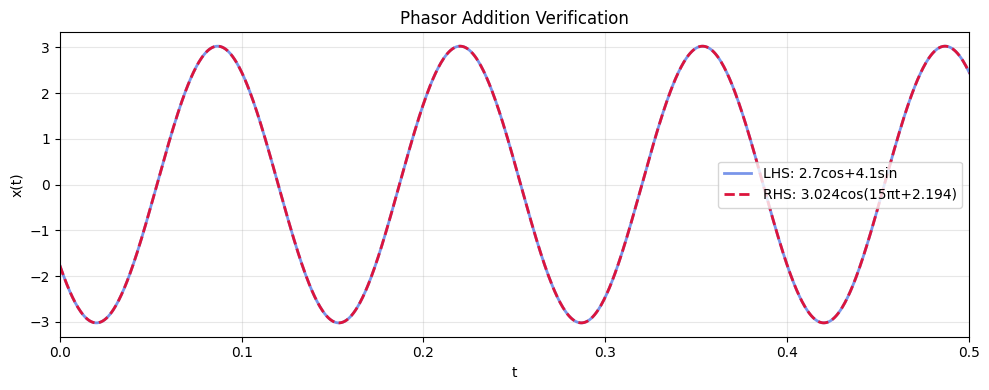

Max difference between LHS and RHS: 1.33e-14 (should be ~0)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Phasor addition example from lecture
# 2.7*cos(15*pi*t + 0.6) + 4.1*sin(15*pi*t - 1.8)
# sin(x) = cos(x - pi/2), so 4.1*sin(15*pi*t-1.8) = 4.1*cos(15*pi*t - 1.8 - pi/2)

A1, phi1 = 2.7,  0.6
A2, phi2 = 4.1, -1.8 - np.pi/2   # sin -> cos: subtract pi/2

phasor1 = A1 * np.exp(1j*phi1)
phasor2 = A2 * np.exp(1j*phi2)
phasor_sum = phasor1 + phasor2

A_result   = abs(phasor_sum)
phi_result = np.angle(phasor_sum)

print('=== Phasor Addition: 2.7cos(15pi t+0.6) + 4.1sin(15pi t-1.8) ===')
print(f'  sin(x) = cos(x-pi/2), so 4.1 sin(15pi t - 1.8) = 4.1 cos(15pi t + {phi2:.4f})')
print(f'  Phasor 1: {A1}*e^(j*{phi1}) = {phasor1.real:.4f}+{phasor1.imag:.4f}j')
print(f'  Phasor 2: {A2}*e^(j*{phi2:.4f}) = {phasor2.real:.4f}+{phasor2.imag:.4f}j')
print(f'  Sum:      {phasor_sum.real:.4f}+{phasor_sum.imag:.4f}j')
print(f'  Result: A={A_result:.4f}, phi={phi_result:.4f} rad')
print(f'  So: 2.7cos+4.1sin = {A_result:.4f}*cos(15*pi*t + {phi_result:.4f})')

# Verify with time-domain plot
t = np.linspace(0, 1, 2000)
lhs = 2.7*np.cos(15*np.pi*t+0.6) + 4.1*np.sin(15*np.pi*t-1.8)
rhs = A_result*np.cos(15*np.pi*t+phi_result)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t, lhs, 'royalblue', lw=2, label='LHS: 2.7cos+4.1sin', alpha=0.7)
ax.plot(t, rhs, 'crimson',   lw=2, ls='--', label=f'RHS: {A_result:.3f}cos(15πt+{phi_result:.3f})')
ax.set_xlim(0,0.5); ax.set_xlabel('t'); ax.set_ylabel('x(t)')
ax.set_title('Phasor Addition Verification'); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

max_diff = np.max(np.abs(lhs-rhs))
print(f'Max difference between LHS and RHS: {max_diff:.2e} (should be ~0)')

---
### 4. Discrete-Time Sinusoids

A discrete-time sinusoid has the general form:
$$x[n] = A\cos(\omega n + \phi) \qquad \text{or in complex form:} \quad z[n] = Ae^{j(\omega n+\phi)}$$

$x[n] = \Re\{z[n]\}$.

The parameter $\omega$ is in **radians/sample** (not rad/sec). There is no physical time.

### 5–6. Frequency Equivalence in Discrete Time

**Key observation 1:** $\omega$ and $\omega+2k\pi$ represent the same frequency:
$$\cos(\omega n+\phi) = \cos((\omega+2k\pi)n+\phi)$$
because $2kn\pi$ is a whole number of revolutions at every integer $n$.

**Key observation 2:** For real sinusoids, $\omega$ and $-\omega$ (equivalently $2\pi-\omega$) describe the same signal:
$$\cos(\omega n+\phi) = \cos(-\omega n-\phi) = \cos((2\pi-\omega)n-\phi)$$
So the **effective range** is $\omega\in[0,\pi]$ for real sinusoids.

> **Insight:** $\omega=0$ gives a constant signal; $\omega=\pi$ gives the highest-frequency alternating signal $\cos(\pi n)=(-1)^n$.


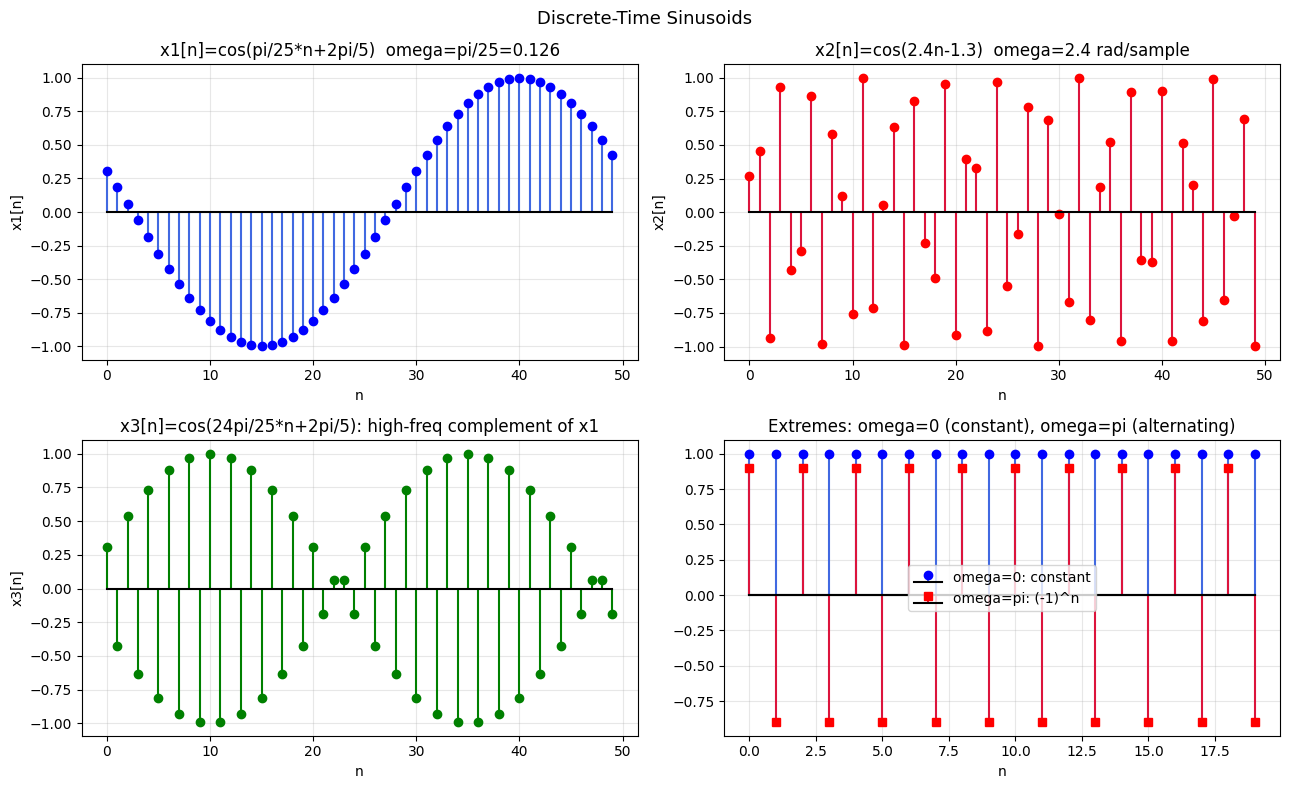

w1 + w3 = pi/25 + 24*pi/25 = 3.1416 = pi = 3.1416
x1 and x3 are complementary frequencies in [0, pi]


In [2]:
# Visualize discrete-time sinusoids and frequency equivalence
n = np.arange(0, 100)
w1 = np.pi/25;  phi1 = 2*np.pi/5
w2 = 2.4;       phi2 = -1.3
x1 = np.cos(w1*n + phi1)
x2 = np.cos(w2*n + phi2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# x1 - low freq, looks like continuous sinusoid
ax = axes[0][0]
ax.stem(n[:50], x1[:50], linefmt='royalblue', markerfmt='bo', basefmt='k')
ax.set_title(f'x1[n]=cos(pi/25*n+2pi/5)  omega=pi/25={np.pi/25:.3f}'); ax.grid(True,alpha=0.3)
ax.set_xlabel('n'); ax.set_ylabel('x1[n]')

ax = axes[0][1]
ax.stem(n[:50], x2[:50], linefmt='crimson', markerfmt='ro', basefmt='k')
ax.set_title(f'x2[n]=cos(2.4n-1.3)  omega=2.4 rad/sample'); ax.grid(True,alpha=0.3)
ax.set_xlabel('n'); ax.set_ylabel('x2[n]')

# High-freq sinusoid x3 = cos((24*pi/25)*n + 2*pi/5)
w3 = 24*np.pi/25; phi3 = 2*np.pi/5
x3 = np.cos(w3*n + phi3)
ax = axes[1][0]
ax.stem(n[:50], x3[:50], linefmt='green', markerfmt='go', basefmt='k')
ax.set_title(f'x3[n]=cos(24pi/25*n+2pi/5): high-freq complement of x1'); ax.grid(True,alpha=0.3)
ax.set_xlabel('n'); ax.set_ylabel('x3[n]')

# omega=0 (constant) and omega=pi (alternating)
ax = axes[1][1]
x_const = np.ones(20)
x_alt   = (-1)**np.arange(20)
ax.stem(np.arange(20), x_const, linefmt='royalblue', markerfmt='bo', basefmt='k', label='omega=0: constant')
ax.stem(np.arange(20), x_alt*0.9, linefmt='crimson', markerfmt='rs', basefmt='k', label='omega=pi: (-1)^n')
ax.set_title('Extremes: omega=0 (constant), omega=pi (alternating)')
ax.legend(); ax.grid(True,alpha=0.3); ax.set_xlabel('n')

plt.suptitle('Discrete-Time Sinusoids', fontsize=13)
plt.tight_layout(); plt.show()

# Show that w1 and 2*pi - w3 are complementary
print(f'w1 + w3 = pi/25 + 24*pi/25 = {w1+w3:.4f} = pi = {np.pi:.4f}')
print(f'x1 and x3 are complementary frequencies in [0, pi]')

---
### 7. Example: Smallest Positive Equivalent Frequency

Express using smallest positive $\omega$:

$$z[n] = e^{j(37\pi/13)n+j\pi/8}$$
Since $37\pi/13 > 2\pi$: $37\pi/13 - 2\pi = 37\pi/13 - 26\pi/13 = 11\pi/13$.
So $z[n] = e^{j(11\pi/13)n+j\pi/8}$.

$$x[n] = \cos\left(\frac{42\pi}{13}n - \frac{5\pi}{6}\right)$$
$42\pi/13 - 2\pi = 16\pi/13 > \pi$. Try $42\pi/13 - 4\pi = -10\pi/13$. Since $\cos(-\theta n)=\cos(\theta n)$:
$x[n] = \cos((10\pi/13)n+5\pi/6)$.

### 8. Low and High Frequency Extremes

- $\omega=0$: $x[n]=A\cos(\phi)$ = **constant**
- $\omega=\pi$: $x[n]=A\cos(\pi n+\phi)=A(-1)^n\cos(\phi)$ = **alternating signal** (highest frequency)

### 9–10. Periodicity of Discrete-Time Sinusoids

$x[n]=\cos(\omega n+\phi)$ is periodic iff $\omega N = 2k\pi$ for integers $k, N$, i.e.:
$$\omega = \frac{k}{N}\cdot 2\pi \quad (\omega \text{ is a rational multiple of } 2\pi)$$

| $\omega$ | Period $N$ |
|---|---|
| $0$ | $1$ |
| $\pi$ | $2$ |
| $1.0$ (irrational multiple of $2\pi$) | $\infty$ (aperiodic) |
| $10\pi/13$ | $13$ |
| $11\pi/13$ | $26$ |

> **Key Insight:** Unlike continuous time where $T=2\pi/\Omega$ always works, in discrete time the fundamental period $N$ must be an **integer**.


=== Smallest Positive Equivalent Frequency ===
Complex: 37pi/13 = 8.9415 rad/sample  (> 2pi=6.2832)
Subtract 2pi: 11pi/13 = 2.6583 rad/sample

Real: 42pi/13 = 10.1498 (> 2pi)
  -2pi: 3.8666 rad  (still > pi)
  -4pi: -2.4166 rad  (negative -> use symmetry cos(-w)=cos(w))
  Result: cos(10pi/13 * n + 5pi/6)

=== Periodicity Examples ===
  omega=0: period = 1
  omega=pi: period = 2
  omega=1.0 (aperiodic): period = inf (aperiodic)
  omega=10pi/13: period = 13
  omega=11pi/13: period = 26


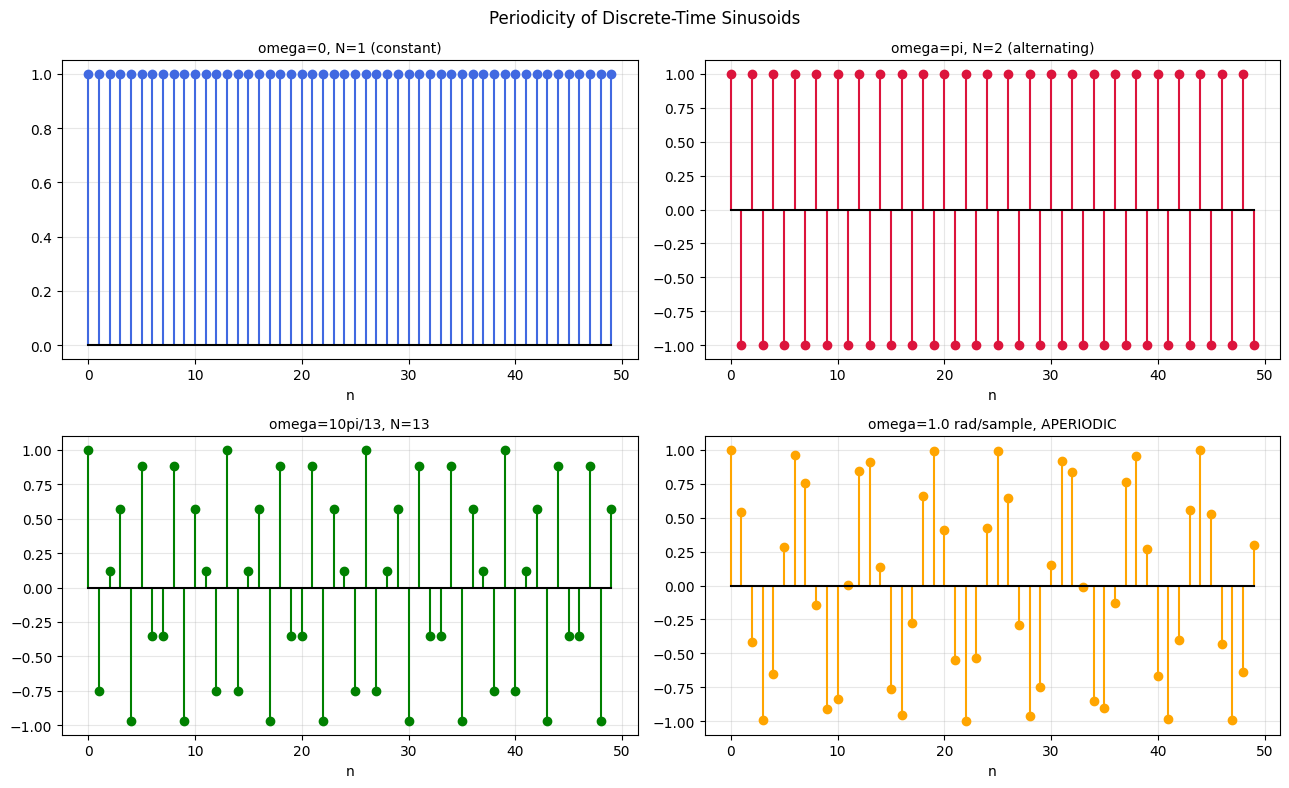

In [3]:
# Frequency reduction
print('=== Smallest Positive Equivalent Frequency ===')
w_complex = 37*np.pi/13
w_reduced = w_complex - 2*np.pi
print(f'Complex: 37pi/13 = {w_complex:.4f} rad/sample  (> 2pi={2*np.pi:.4f})')
print(f'Subtract 2pi: 11pi/13 = {w_reduced:.4f} rad/sample')
print()
w_real = 42*np.pi/13
print(f'Real: 42pi/13 = {w_real:.4f} (> 2pi)')
print(f'  -2pi: {w_real-2*np.pi:.4f} rad  (still > pi)')
print(f'  -4pi: {w_real-4*np.pi:.4f} rad  (negative -> use symmetry cos(-w)=cos(w))')
print(f'  Result: cos(10pi/13 * n + 5pi/6)')

# Periodicity demonstration
print('\n=== Periodicity Examples ===')
test_omegas = [(0, 'omega=0'), (np.pi, 'omega=pi'), (1.0, 'omega=1.0 (aperiodic)'), 
               (10*np.pi/13, 'omega=10pi/13'), (11*np.pi/13, 'omega=11pi/13')]
for w, name in test_omegas:
    x = np.cos(w*np.arange(200))
    # Find period: find smallest N such that x[n+N] == x[n] for all n
    period = None
    for N in range(1, 101):
        if np.allclose(x[:50], np.roll(x,-N)[:50], atol=1e-10):
            period = N; break
    print(f'  {name}: period = {period if period else "inf (aperiodic)"}')

# Visualize periodic vs aperiodic
fig, axes = plt.subplots(2,2,figsize=(13,8))
n = np.arange(50)
cases = [(0,'royalblue','omega=0, N=1 (constant)'),
         (np.pi,'crimson','omega=pi, N=2 (alternating)'),
         (10*np.pi/13,'green','omega=10pi/13, N=13'),
         (1.0,'orange','omega=1.0 rad/sample, APERIODIC')]
for ax, (w,col,title) in zip(axes.flat, cases):
    ax.stem(n, np.cos(w*n), linefmt=col, markerfmt=f'o', basefmt='k')
    ax.set_title(title, fontsize=10); ax.grid(True,alpha=0.3); ax.set_xlabel('n')
plt.suptitle('Periodicity of Discrete-Time Sinusoids', fontsize=12)
plt.tight_layout(); plt.show()

---
## Summary

| Concept | Formula |
|---|---|
| Stationary phasor | $Ae^{j\phi}$ |
| Phasor sum | $Ae^{j\phi}=A_1e^{j\phi_1}+A_2e^{j\phi_2}$ |
| DT sinusoid | $x[n]=A\cos(\omega n+\phi)$ |
| Freq equivalence | $\omega \equiv \omega+2k\pi$ |
| Real sinusoid symmetry | $\omega \equiv 2\pi-\omega$ |
| Periodicity condition | $\omega=(k/N)\cdot 2\pi$ |

### Mistakes to Avoid
1. Adding sinusoid amplitudes directly — use **phasor addition**.
2. Forgetting to convert `sin` to `cos` (subtract $\pi/2$) before computing phasors.
3. Assuming all DT sinusoids are periodic — they're not unless $\omega$ is a rational multiple of $2\pi$.
4. Confusing $\omega$ (rad/sample) with $\Omega$ (rad/sec).
